In [1]:
import numpy as np
import sympy as sp
from matplotlib import pyplot as plt

EJERCICIO 1

1.

In [2]:
x = np.linspace(0,1,50)

In [3]:
media = 0
desviacion_estandar = 0.2
n_muestras = 50
ruido = np.random.normal(loc=media, scale=desviacion_estandar, size=n_muestras)

In [4]:
y = np.sin(2*(np.pi)*x) + ruido

In [5]:
def obtener_puntos(x, y):
  puntos = []
  for i in range(len(x)):
    P = np.array([x[i], y[i]])
    puntos.append(P)
  return puntos

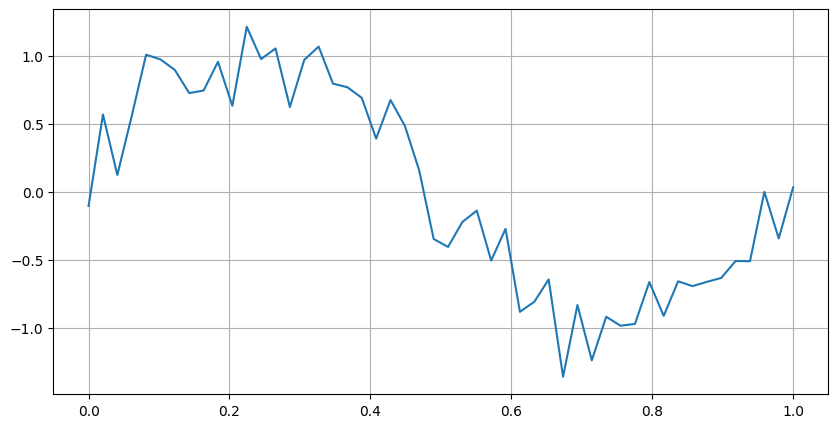

In [6]:
plt.figure(figsize=(10,5))
plt.plot(x,y)
plt.grid()
plt.show()

2.

i)

In [7]:

n = 5

In [8]:
def V(x_vector, degree):
  V = np.vander(x_vector, N=degree + 1, increasing=True)
  return V


In [9]:
def ecuaciones_normales(A,y):
  A_transpuesta = np.transpose(A)
  matriz = A_transpuesta @ A
  v = A_transpuesta @ y
  res = np.linalg.solve(matriz,v)
  return res

In [10]:
print(ecuaciones_normales(V(x,n),y))

[  0.15489609   5.82755524   4.5825239  -83.89585999 125.36373649
 -52.08305639]


ii)

In [11]:
Q,R = np.linalg.qr(V(x,n))

In [12]:
Q_transpuesta = np.transpose(Q)
M = Q_transpuesta @ y
Factorizacion_QR = np.linalg.solve(R,M)

In [13]:
print(Factorizacion_QR)

[  0.15489609   5.82755523   4.5825239  -83.89586    125.3637365
 -52.0830564 ]


iii)

In [14]:
metodo_SVD = np.linalg.lstsq(V(x,n), y)[0]

In [15]:
print(metodo_SVD)

[  0.15489609   5.82755523   4.5825239  -83.89586    125.3637365
 -52.0830564 ]


3.

In [16]:
n0 = 5
n1 = 10
n2 = 15
n3 = 20
V0 = V(x,n0)
V1 = V(x,n1)
V2 = V(x,n2)
V3 = V(x,n3)

In [17]:
ecuaciones_normales0 = ecuaciones_normales(V0,y)
ecuaciones_normales1 = ecuaciones_normales(V1,y)
ecuaciones_normales2 = ecuaciones_normales(V2,y)
ecuaciones_normales3 = ecuaciones_normales(V3,y)

In [18]:
ecuaciones_normales1

array([-4.73778099e-02,  1.72600696e+01, -8.43568042e+01, -4.54877215e+02,
        6.90796653e+03, -3.28469747e+04,  8.22754429e+04, -1.20579804e+05,
        1.04321974e+05, -4.95291003e+04,  9.97253659e+03])

In [19]:
Q0,R0 = np.linalg.qr(V(x,n0))
Q1,R1 = np.linalg.qr(V(x,n1))
Q2,R2 = np.linalg.qr(V(x,n2))
Q3,R3 = np.linalg.qr(V(x,n3))
Q0_transpuesta = np.transpose(Q0)
Q1_transpuesta = np.transpose(Q1)
Q2_transpuesta = np.transpose(Q2)
Q3_transpuesta = np.transpose(Q3)
M0 = Q0_transpuesta @ y
M1 = Q1_transpuesta @ y
M2 = Q2_transpuesta @ y
M3 = Q3_transpuesta @ y
Factorizacion_QR0 = np.linalg.solve(R0,M0)
Factorizacion_QR1 = np.linalg.solve(R1,M1)
Factorizacion_QR2 = np.linalg.solve(R2,M2)
Factorizacion_QR3 = np.linalg.solve(R3,M3)

In [20]:
metodo_SVD0 = np.linalg.lstsq(V0, y)[0]
metodo_SVD1 = np.linalg.lstsq(V1, y)[0]
metodo_SVD2 = np.linalg.lstsq(V2, y)[0]
metodo_SVD3 = np.linalg.lstsq(V3, y)[0]

In [21]:
def evaluacion(v,x):
  out = 0
  for i in range(len(v)):
    out = out + v[i] * x**(i)
  res = out
  return res




In [22]:
def evaluacion2(v,a):
  lista = []
  for i in range(len(a)):
    nueva_lista = evaluacion(v,a[i])
    lista.append(nueva_lista)
  return lista

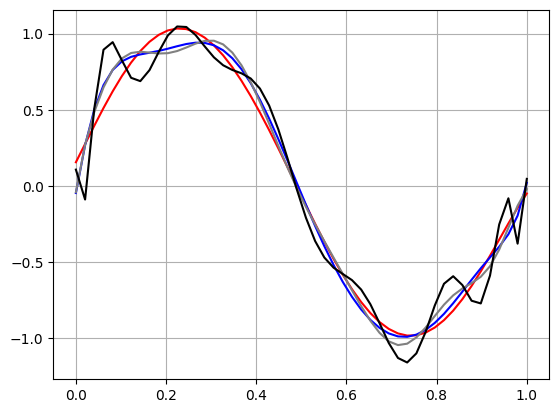

In [23]:
plt.plot(x,evaluacion2(ecuaciones_normales0,x),"r")
plt.plot(x,evaluacion2(ecuaciones_normales1,x),"b")
plt.plot(x,evaluacion2(ecuaciones_normales2,x),"grey")
plt.plot(x,evaluacion2(ecuaciones_normales3,x),"k")
plt.grid()
plt.show()

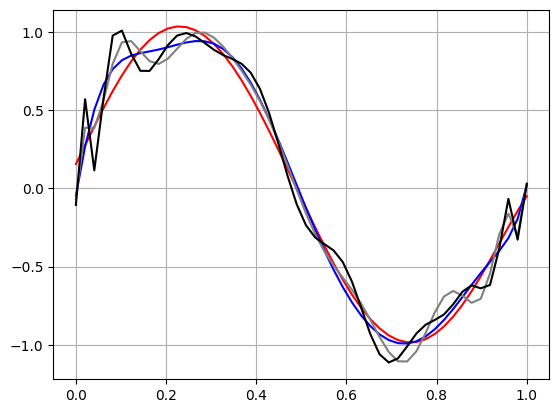

In [24]:
plt.plot(x,evaluacion2(Factorizacion_QR0,x),"r")
plt.plot(x,evaluacion2(Factorizacion_QR1,x),"b")
plt.plot(x,evaluacion2(Factorizacion_QR2,x),"grey")
plt.plot(x,evaluacion2(Factorizacion_QR3,x),"k")
plt.grid()
plt.show()

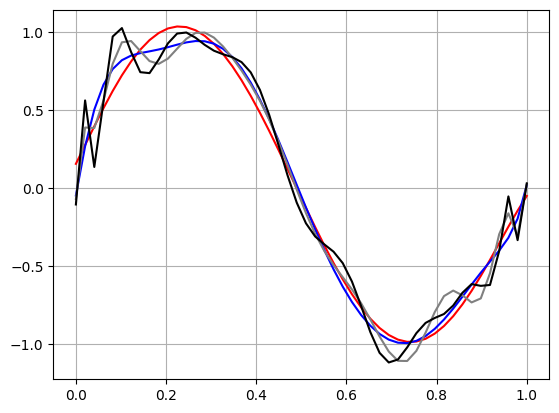

In [25]:
plt.plot(x,evaluacion2(metodo_SVD0,x),"r")
plt.plot(x,evaluacion2(metodo_SVD1,x),"b")
plt.plot(x,evaluacion2(metodo_SVD2,x),"grey")
plt.plot(x,evaluacion2(metodo_SVD3,x),"k")
plt.grid()
plt.show()

4.

In [26]:
def numero_condicion(V):
  res = np.linalg.cond(V,2)
  return res

In [27]:
print(numero_condicion(V(x,n)))
print(numero_condicion(V1))
print(numero_condicion(V2))
print(numero_condicion(V3))

3547.3242673902
20356629.64290608
137767982217.56964
1145297218664043.0


In [28]:
def numero_condicion2(A):
  A_transpuesta = np.transpose(A)
  matriz = A_transpuesta @ A
  res = np.linalg.cond(matriz,2)
  return res

In [29]:
print(numero_condicion2(V(x,n)))
print(numero_condicion2(V1))
print(numero_condicion2(V2))
print(numero_condicion2(V3))

12583509.455636472
414175361888342.6
1.0462617777673085e+19
1.2039927251042217e+18


5.

In [30]:
ecuaciones_normales = ecuaciones_normales(V(x,n),y)
error1= np.linalg.norm(ecuaciones_normales - metodo_SVD)
error2= np.linalg.norm(ecuaciones_normales1 - metodo_SVD1)
error3= np.linalg.norm(ecuaciones_normales2 - metodo_SVD2)
error4= np.linalg.norm(ecuaciones_normales3 - metodo_SVD3)

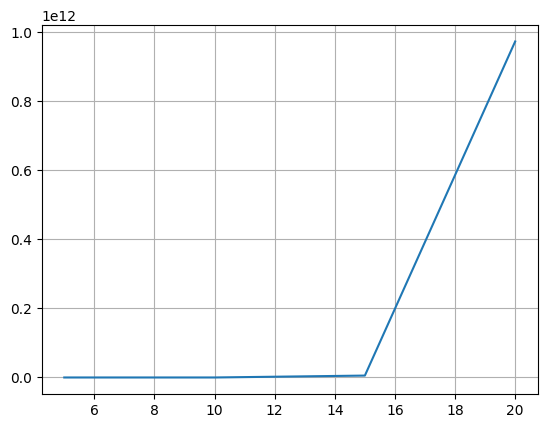

In [31]:
valores_n= [5,10,15,20]
lista_de_errores = [error1,error2,error3,error4]
plt.plot(valores_n,lista_de_errores)
plt.grid()
plt.show()


In [32]:
print(error1)
print(error2)
print(error3)
print(error4)

1.52064439838298e-08
135.96235370271052
5494932013.867234
972387104272.1216
